# Homework: Learning Audio Representations with Self-Supervision

In this homework, we will consolidate the knowledge gained during the seminar and further explore methods for self-supervised learning of audio representations.
During the seminar, we implemented and trained a model based on contrastive learning (InfoNCE). Now, we will extend this work by implementing non-contrastive learning (NCL) approaches and comparing them with previously studied methods.

We will examine how different training paradigms — supervised, contrastive, and non-contrastive — affect the quality of learned embeddings and the stability of the training process


## Multi-Format Contrastive Learning of Audio Representations(Paper from seminar)

The core idea of this approach is to learn robust audio embeddings by contrasting
different *formats* (or views) of the same audio sample.  
For example, one branch may encode the **raw waveform (1D)** while another encodes
its **spectrogram (2D)**.  

By applying a contrastive loss (InfoNCE), the model is trained to:
- **Pull together** embeddings from different formats of the same audio,
- **Push apart** embeddings from different audio samples.  

This multi-format setup encourages the encoder to capture **shared semantic content**
across input representations, leading to more general and transferable audio features.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

## AudioSet

Dataset with 10 numbers pronounced
```
!git clone https://github.com/soerenab/AudioMNIST.git
```



In [1]:
# !git clone https://github.com/soerenab/AudioMNIST.git

In [2]:
# !mkdir models

## Dependencies

In [3]:
import gc
import os
import random
import torchaudio
import torchaudio.transforms as T
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio
from pathlib import Path
from omegaconf import DictConfig
import copy
import json

import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from tqdm.notebook import tqdm, tnrange
from torch.utils.data import Subset, DataLoader
from torchaudio import transforms
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')
# warnings.filterwarnings("ignore", module="torchaudio._backend")

plt.rcParams.update({'font.size': 14})

In [4]:
#check for cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Available device:", device)

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# syncing cuda, clearing cache
def clear_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()

    gc.collect()

Available device: cuda


In [5]:
# Фиксация всех источников случайности
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

In [6]:
root = '../AudioMNIST/data'
rand_speaker = random.choice(os.listdir(root))
rand_audio = random.choice(os.listdir(os.path.join(root, rand_speaker)))
print(f'Speaker #{rand_speaker}, class #{rand_audio[0]}')

# waveform, sample_rate = torchaudio.load(
#     os.path.join(root, rand_speaker, rand_audio), normalize=True
# )

y, sample_rate = librosa.load(
    os.path.join(root, rand_speaker, rand_audio), sr=None, mono=True)

waveform = torch.from_numpy(y).float().unsqueeze(0)
waveform = waveform / (waveform.abs().max() + 1e-8)

print(f'Sample rate: {sample_rate}, waveform shape: {waveform.shape}')
Audio(waveform, rate=sample_rate)

Speaker #41, class #1
Sample rate: 48000, waveform shape: torch.Size([1, 29735])


In [7]:
new_sample_rate = 16000
resample = T.Resample(orig_freq=sample_rate, new_freq=new_sample_rate)
resampled_waveform = resample(waveform)
Audio(resampled_waveform, rate=new_sample_rate)

In [8]:
class LogMelSpectrogram(T.MelSpectrogram):
    def __init__(self, eps=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def forward(self, waveform):
        return (super().forward(waveform) + self.eps).log()

Spectrogram shape: torch.Size([64, 50])
Values range: ((tensor(-12.9961), tensor(5.6578)))


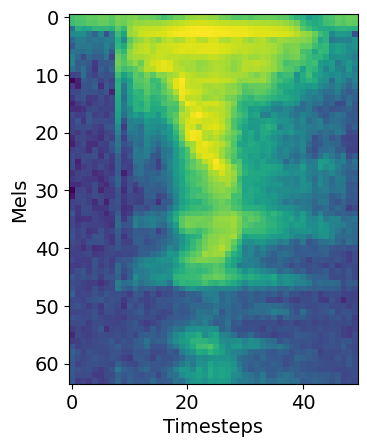

In [9]:
spectrogram = LogMelSpectrogram(sample_rate=16000, n_mels=64)
logmel_spec = spectrogram(resampled_waveform.squeeze())
print(f'Spectrogram shape: {logmel_spec.shape}')
print(f'Values range: ({logmel_spec.min(), logmel_spec.max()})')

plt.imshow(logmel_spec.numpy())
plt.ylabel('Mels')
plt.xlabel('Timesteps')
plt.show()

In [10]:
# добавлена возможность выбора типа/формата представления: waveform/spectrogram
class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root, sr=16000, return_format='waveform'):
        self.root = root
        self.sr = sr
        self.return_format = return_format
        self.items = self.list_wavs_and_labels(root)

        # вычисление спектрограммы, если выбран этот формат
        if self.return_format == 'spectrogram':
            self.to_spec = LogMelSpectrogram(
                sample_rate=self.sr,
                n_fft=2048,
                hop_length=128,
                n_mels=128,
                f_min=40,
                f_max=8000,
                mel_scale="slaney"
            )

    def __len__(self):
        return len(self.items)

    def list_wavs_and_labels(self, root: str):
        base = Path(root)
        speakers = sorted([p for p in base.iterdir() if p.is_dir()])
        items = []
        for sp in speakers:
            for wav in sorted(sp.glob("**/*.wav")):
                name = wav.stem.split("_")
                digit = int(name[0])
                speaker_id = sp.name
                items.append((str(wav), digit, speaker_id))
        return items

    def load_wav(self, path):

        y, sr = librosa.load(path, sr=None, mono=True)
        wav = torch.from_numpy(y).float().unsqueeze(0)

        # wav, sr = torchaudio.load(path)  # [C, T]
        
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]
        return wav

    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)

        if self.return_format == 'spectrogram':
            # Формат для ResNet2D: [1, 64, T_spec]
            return self.to_spec(wav), label
        else:
            # Формат для ResNet1D: [1, T]
            return wav, label

# без изменений
# def collate(batch):
#     wavs, labels = zip(*batch)
#     wavs = nn.utils.rnn.pad_sequence([w.squeeze(0).t() for w in wavs], batch_first=True)  # [B, Tw, 1]? we transposed; fix:
#     wavs = nn.utils.rnn.pad_sequence([w.squeeze(0) for w in wavs], batch_first=True)  # [B, T]
#     labels = torch.tensor(labels, dtype=torch.long)
#     return wavs, labels

In [11]:
# Ensure data loading correctly
_test_dataset = AudioMNISTDataset(root, return_format='waveform')
_test_dataset[0][0].shape

torch.Size([1, 11959])

In [12]:
# Ensure data loading correctly
_test_dataset = AudioMNISTDataset(root, return_format='spectrogram')
_test_dataset[0][0].shape

torch.Size([1, 128, 94])

In [13]:
def split_indices_by_speaker(dataset: AudioMNISTDataset, test_speakers: set):
    train_idxs = []
    test_idxs = []
    for idx, (_, _, spk) in enumerate(dataset.items):
        if spk in test_speakers:
            test_idxs.append(idx)
        else:
            train_idxs.append(idx)
    return train_idxs, test_idxs


# Split dataset by speakers
NUM_TEST_SPEAKERS = 12
full_ds = AudioMNISTDataset(root=root)
all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)
train_ds = Subset(full_ds, train_idxs)
valid_ds = Subset(full_ds, valid_idxs)

## Convolutional encoders

---

#### **1. ResNet1D – for raw waveforms**
- **Input:** `[batch, 1, time]`  
- **First layer:** `Conv1d(7, stride=2)` → BatchNorm → ReLU → MaxPool1d  
- **Residual blocks:** `[2, 2, 2, 2]` blocks with channels `[64, 128, 256, 512]`  
- **Each block:** `Conv1d(1x1)` + `Conv1d(3x3)` with skip connection  
- **Output:** Global average pooled feature `[batch, 512, 1]`  

This encoder *slides filters along the time axis* to capture **temporal patterns** in raw waveforms.

---

#### **2. ResNet2D – for spectrograms**
- **Input:** `[batch, channels, height, width]`  
- **First layer:** `Conv2d(7x7, stride=2)` → BatchNorm → ReLU → MaxPool2d  
- **Residual blocks:** `[2, 2, 2, 2]` blocks with channels `[64, 128, 256, 512]`  
- **Each block:** `Conv2d(1x1)` + `Conv2d(3x3)` with skip connection  
- **Output:** Global average pooled feature `[batch, 512, 1, 1]`  

This encoder *slides filters along time and frequency dimensions* to capture **spectro-temporal patterns** in spectrograms.

---


In [14]:
class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block, self).__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

class ResNet1D(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block):
        super(ResNet1D, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv1d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(output_size=1)


        # size after avgpool = [32, 512, 1]

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        #x = x.reshape(x.shape[0], -1)
        #x = self.fc(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv1d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm1d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)



def CreateResNet1D():
    return ResNet1D(block)



class block_resnet2d(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block_resnet2d, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

class ResNet(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block, image_channels):
        super(ResNet, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))


    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm2d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)



def CreateResNet2D(img_channels=3):
    return ResNet(block_resnet2d, image_channels=img_channels)



## Implement model

In [15]:
class Net(nn.Module):

    def __init__(self, img_channels = 1, num_classes = 35):
        super(Net, self).__init__()
        ####################### ENCODER ###################################
        self.resnet_1D = CreateResNet1D()
        self.resnet_2D = CreateResNet2D(img_channels=img_channels)

        self.output = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        ####################################################################

    # порядок аргументов исправлен: теперь одинаков на вход и на выход
    def forward(self, input_audio, input_spectogram):
        """
            resnet2d and resnet1d output is [BS, 512, 1, 1]
            Output:
                - audio_emb, specs_emb used for contrastive loss
                - audio, spectograms used for Evaluation layer
                - output used for semi supervised - cross entropy
        """

        audio = self.resnet_1D(input_audio)
        audio = audio.squeeze()
        spectograms = self.resnet_2D(input_spectogram)
        spectograms = spectograms.squeeze()

        audio_emb = self.output(audio)
        specs_emb = self.output(spectograms)

        return audio_emb, specs_emb, audio, spectograms


class EvaluationHead(nn.Module):
    """
    Linear classifier head
    """
    def __init__(self, num_classes = 35):
        super(EvaluationHead, self).__init__()

        self.evaluation = nn.Sequential(
                    nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x = self.evaluation(x)
        return x

In [16]:
def device_as(t1, t2):
   return t1.to(t2.device)

class ContrastiveLoss(nn.Module):
  def __init__(self, temperature=0.5):
    super().__init__()
    self.temperature = temperature

  def calc_similarity_batch(self, a, b):
    rep = torch.cat([a,b])
    return F.cosine_similarity(rep.unsqueeze(1), rep.unsqueeze(0), dim=2)

  def forward(self, proj_1, proj_2):
    batch_size = proj_1.shape[0]
    z_i = F.normalize(proj_1, p=2, dim=1)
    z_j = F.normalize(proj_2, p=2, dim=1)

    similarity_matrix = self.calc_similarity_batch(z_i, z_j)

    #######
    #aa#ab#
    #######
    #ba#bb#
    #######

    sim_ij = torch.diag(similarity_matrix, batch_size)
    sim_ji = torch.diag(similarity_matrix, -batch_size)

    positives = torch.cat([sim_ij, sim_ji])

    nominator = torch.exp(positives / self.temperature)

    mask = (~torch.eye(batch_size*2, batch_size*2).bool()).float()
    mask = device_as(mask, similarity_matrix)

    denominator = mask * torch.exp(similarity_matrix / self.temperature)
    all_losses = -torch.log(nominator / torch.sum(denominator, dim=1))
    loss = torch.sum(all_losses) / (2*batch_size)

    return loss




## Task 1(2 points)

Implement straightforward classifier training based on waveforms or spectrogram(use models from seminar). Train it in supervised manner and compute accuracy

Аугментации здесь не использую, поскольку задача -- получить бэйзлайн.

In [17]:
def save_best_checkpoint(model, accuracy, epoch, best_acc, save_path):
    if accuracy > best_acc:
        best_acc = accuracy

        state_dict_copy = copy.deepcopy(model.state_dict())
        torch.save({
            'epoch': epoch,
            'model_state_dict': state_dict_copy,
            'accuracy': accuracy
        }, save_path)
        print(f"  -> New best accuracy: {accuracy:.2f}%. Checkpoint saved to {save_path}")
    return best_acc

def load_best_weights(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    return model

def save_history_to_json(history, filepath):
    with open(filepath, 'w') as f:
        json.dump(history, f, indent=4)

def read_json(json_path):
    with open(json_path, 'r') as file:
        data = json.load(file)
    return data

In [18]:
class AudioClassifier(nn.Module):
    def __init__(self, input_format='waveform', num_classes=10):
        super().__init__()

        # тип представления на вход
        if input_format == 'waveform':
            self.encoder = CreateResNet1D()
        else:  # 'spectrogram'
            self.encoder = CreateResNet2D(img_channels=1)

        # линейная голова для классификации
        self.head = EvaluationHead(num_classes=num_classes)

    def forward(self, x):
        # [B, 512, 1] для 1D; [B, 512, 1, 1] для 2D
        features = self.encoder(x)

        # -> [B, 512]
        features = features.squeeze()

        # логиты классов: [B, num_classes]
        logits = self.head(features)
        return logits

In [19]:
def train_and_evaluate(format_type='waveform', epochs=10, lr=3e-4, batch_size=64):
    # подготовка данных (датасет пересобирается под представление)
    full_ds = AudioMNISTDataset(root=root, return_format=format_type)
    all_speakers = sorted({spk for (_, _, spk) in full_ds.items})
    valid_speakers = set(all_speakers[-NUM_TEST_SPEAKERS:])
    train_idxs, valid_idxs = split_indices_by_speaker(full_ds, valid_speakers)

    train_ds = Subset(full_ds, train_idxs)
    valid_ds = Subset(full_ds, valid_idxs)

    # коллатор для нового датасета
    def collate_fn(batch):
        inputs, labels = zip(*batch)
        labels = torch.tensor(labels, dtype=torch.long)

        if format_type == 'waveform':
            # [1, T] -> [B, 1, T_max]
            max_len = max([x.shape[-1] for x in inputs])
            inputs_padded = torch.zeros(len(inputs), 1, max_len)
            for i, x in enumerate(inputs):
                inputs_padded[i, 0, :x.shape[-1]] = x[0]

        else:  # 'spectrogram'
            # [1, Mels, T] -> [B, 1, Mels, T_max]
            mels = inputs[0].shape[1]
            max_len = max([x.shape[-1] for x in inputs])
            inputs_padded = torch.zeros(len(inputs), 1, mels, max_len)
            for i, x in enumerate(inputs):
                inputs_padded[i, 0, :, :x.shape[-1]] = x[0]

        return inputs_padded, labels

    train_loader = DataLoader(train_ds,
                              batch_size=batch_size,
                              shuffle=True,
                              collate_fn=collate_fn,
                              num_workers=0)
    valid_loader = DataLoader(valid_ds,
                              batch_size=batch_size * 2, # можно увеличить
                              shuffle=False,
                              collate_fn=collate_fn,
                              num_workers=0)

    # инициализация модели, лосса и оптимизатора
    model = AudioClassifier(input_format=format_type, num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_acc = 0.0
    save_path = f"best_model_{format_type}.pt"
    history = {'loss': [],
               'accuracy': []}
    json_path = f"history_{format_type}.json"

    # цикл обучения
    for epoch in tnrange(epochs, desc=f'Training ({format_type})'):
        model.train()
        running_loss = 0.0

        train_pbar = tqdm(train_loader,
                          desc=f"Epoch {epoch + 1}/{epochs} [Train]",
                          leave=False)
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            train_pbar.set_postfix(loss=f"{loss.item():.4f}")

        # фаза оценивания
        model.eval()
        total = 0
        correct = 0

        with torch.no_grad():
            valid_pbar = tqdm(valid_loader,
                              desc=f'Epoch {epoch + 1}/{epochs} [Valid]',
                              leave=False)
            for inputs, labels in valid_pbar:
                inputs, labels = inputs.to(device), labels.to(device)

                logits = model(inputs)
                _, predicted = torch.max(logits, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / total
        best_acc = save_best_checkpoint(model, acc, epoch + 1, best_acc, save_path)
        avg_loss = running_loss / len(train_loader)
        print(f'Epoch {epoch+1}:'
              f' Loss = {avg_loss:.4f} | Valid Accuracy = {acc:.2f}%\n')
        history['loss'].append(avg_loss)
        history['accuracy'].append(acc)

    # подгрузка наилучших весов в чистую модель той же архитектуры
    best_model = AudioClassifier(input_format=format_type, num_classes=10).to(device)
    best_model = load_best_weights(best_model, save_path, device)

    # сохранение истории
    save_history_to_json(history, json_path)

    return best_model

#### 1D (waveforms)

In [20]:
# Обучение модели на сырых аудиоволнах (ResNet1D)
model_1d = train_and_evaluate(format_type='waveform', epochs=5)

Training (waveform):   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/5 [Valid]:   0%|          | 0/47 [00:00<?, ?it/s]

  -> New best accuracy: 81.48%. Checkpoint saved to best_model_waveform.pt
Epoch 1: Loss = 0.3700 | Valid Accuracy = 81.48%



Epoch 2/5 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

...

Epoch 4/5 [Valid]:   0%|          | 0/47 [00:00<?, ?it/s]

  -> New best accuracy: 90.60%. Checkpoint saved to best_model_waveform.pt
Epoch 4: Loss = 0.0489 | Valid Accuracy = 90.60%



Epoch 5/5 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 5/5 [Valid]:   0%|          | 0/47 [00:00<?, ?it/s]

  -> New best accuracy: 92.03%. Checkpoint saved to best_model_waveform.pt
Epoch 5: Loss = 0.0412 | Valid Accuracy = 92.03%



#### 2D (spectrograms)

In [21]:
# Обучение модели на лог-мел спектрограммах (ResNet2D)
model_2d = train_and_evaluate(format_type='spectrogram', epochs=5)

Training (spectrogram):   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/5 [Valid]:   0%|          | 0/47 [00:00<?, ?it/s]

  -> New best accuracy: 96.03%. Checkpoint saved to best_model_spectrogram.pt
Epoch 1: Loss = 0.1197 | Valid Accuracy = 96.03%



Epoch 2/5 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

...

Epoch 4/5 [Valid]:   0%|          | 0/47 [00:00<?, ?it/s]

  -> New best accuracy: 98.65%. Checkpoint saved to best_model_spectrogram.pt
Epoch 4: Loss = 0.0137 | Valid Accuracy = 98.65%



Epoch 5/5 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 5/5 [Valid]:   0%|          | 0/47 [00:00<?, ?it/s]

  -> New best accuracy: 99.02%. Checkpoint saved to best_model_spectrogram.pt
Epoch 5: Loss = 0.0034 | Valid Accuracy = 99.02%



За бэйзлайн принят вариант с использованием спектрограмм.

## Task 2(2 points)

Train the Multi-Format Contrastive Learning of Audio Representations model (implemented during the seminar) until convergence. Plot the loss and accuracy curves to verify that the training process has stabilized.

WHY LINEAR PROBE:
Замораживаем обученный SSL-энкодер и обучаем только линейную голову, чтобы оценить полезность извлеченных признаков.

In [22]:
def evaluate_linear_probe(encoder, train_loader, valid_loader, device, probe_epochs=3):
    # глубоко копируем энкодер, чтобы не сломать основную модель
    probe_encoder = copy.deepcopy(encoder)
    for p in probe_encoder.parameters():
        p.requires_grad = False

    head = EvaluationHead(num_classes=10).to(device)
    optimizer = optim.Adam(head.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # обучеаем только голову классификатора
    for probe_epoch in tnrange(probe_epochs,
                     desc='Probing...',
                     leave=False):
        probe_encoder.eval()
        head.train()

        for inputs, labels in tqdm(train_loader,
                                   desc=f'Linear probe: Head training (epoch {probe_epoch + 1}/{probe_epochs})',
                                   leave=False):
            inputs, labels = inputs.to(device), labels.to(device)

            with torch.no_grad():
                feats = probe_encoder(inputs).squeeze()

            logits = head(feats)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


    # оценка accuracy на валидации
    probe_encoder.eval()
    head.eval()

    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(valid_loader,
                                   desc='Linear probe: Head evaluating',
                                   leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            feats = probe_encoder(inputs).squeeze()
            logits = head(feats)
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [23]:
# коллатор для основного цикла (на основе семинара) без аугментаций
def collate_ssl(batch):
    wavs, labels = zip(*batch)
    # выравниваем по времени для сборки в батч: -> [B, T]
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0) for w in wavs], batch_first=True)

    # добавляем канал: [B, T] -> [B, 1, T] (батч, канал, время)
    wavs = wavs.unsqueeze(1)

    labels = torch.tensor(labels, dtype=torch.long)
    return wavs, labels

# коллатор для пайплайна с аугментациями
def collate_ssl_aug(batch):
    wavs, labels = zip(*batch)
    wavs = nn.utils.rnn.pad_sequence([w.squeeze(0) for w in wavs], batch_first=True)  # [B, T]
    labels = torch.tensor(labels, dtype=torch.long)
    return wavs, labels

# коллатор для probe (только спектрограммы)
def probe_collate(batch):
    inputs, labels = zip(*batch)
    mels = inputs[0].shape[1]
    max_len = max([x.shape[-1] for x in inputs])
    inputs_padded = torch.zeros(len(inputs), 1, mels, max_len)
    for i, x in enumerate(inputs):
        inputs_padded[i, 0, :, :x.shape[-1]] = x[0]
    return inputs_padded, torch.tensor(labels, dtype=torch.long)

In [24]:
# аугментации

def fade_in_out(audio):
    assert audio is not None, "audio should not be None"
    _fade_shape = ['linear', 'logarithmic', 'exponential']
    # Защита от слишком коротких аудио
    max_fade = max(1, int(audio.shape[2] / 2))
    _fade_size = [i for i in range(1, max_fade)]

    transform = T.Fade(fade_in_len=random.choice(_fade_size),
                       fade_out_len=random.choice(_fade_size),
                       fade_shape=random.choice(_fade_shape))
    return transform(audio)

def timemasking(waveform, batch_size):
    bs, ch, length = waveform.shape
    mask_len = length // 8
    augmented = waveform.clone()
    for i in range(bs):
        start = random.randint(0, length - mask_len)
        augmented[i, :, start:start + mask_len] = 0.0
    return augmented

In [25]:
def train_ssl_loop(max_epochs=20, probe_step=3, augment=False, ssl_loss=ContrastiveLoss):
    # загрузчики для SSL (нужны оба формата одновременно)
    # num_workers=0 для стабильности в Colab
    ssl_dataset = AudioMNISTDataset(root=root, return_format='waveform')
    ssl_train_ds = Subset(ssl_dataset, train_idxs)

    # при аугментации -- коллатор без добавления канала
    collate_fn = collate_ssl_aug if augment else collate_ssl

    ssl_train_loader = DataLoader(ssl_train_ds, batch_size=64, shuffle=True,
                                  num_workers=0, collate_fn=collate_fn)

    # датасеты/загрузчики для linear probe (только спектрограммы)
    probe_full_ds = AudioMNISTDataset(root=root, return_format='spectrogram')
    probe_train_ds = Subset(probe_full_ds, train_idxs)
    probe_valid_ds = Subset(probe_full_ds, valid_idxs)

    probe_train_loader = DataLoader(probe_train_ds,
                                    batch_size=128,
                                    shuffle=True,
                                    num_workers=0,
                                    collate_fn=probe_collate)
    probe_valid_loader = DataLoader(probe_valid_ds,
                                    batch_size=128 * 2,
                                    shuffle=False,
                                    num_workers=0,
                                    collate_fn=probe_collate)

    # инициализация классов модели и др.
    model = Net(img_channels=1, num_classes=10).to(device)

    # InfoNCE / VicReg
    criterion = ssl_loss().to(device)

    # г/п оптимизатора -- как в семинаре
    optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-6)
    mel_transform = LogMelSpectrogram(sample_rate=16000, n_fft=2048,
                                      hop_length=128, n_mels=128,
                                      f_min=40, f_max=8000,
                                      mel_scale="slaney").to(device)

    # переменные состояний (+ чекпоинты и логика продолжения обучения)
    resume_path = "resume_ssl.pt"
    best_path = "best_ssl.pt"
    json_path = "ssl_history.json"

    start_epoch = 0
    best_acc = 0.0
    loss_history = []
    acc_history = []
    epochs_tracked = []

    # загрузка из чекпоинта (контур 1) для продолжения в новой сессии
    if os.path.exists(resume_path):
        print("Loading params from ckpt...")
        ckpt = torch.load(resume_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        best_acc = ckpt['best_acc'] # скор лучшей модели
        loss_history = ckpt['loss_history']
        acc_history = ckpt['acc_history']
        epochs_tracked = ckpt['epochs_tracked']
        print(f"Starting from epoch {start_epoch}, best acc = {best_acc:.2f}%")

    # цикл обучения
    for epoch in tnrange(start_epoch, max_epochs, desc='Training', leave=True):
        model.train()
        running_loss = 0.0

        pbar = tqdm(ssl_train_loader,
                    desc=f"Epoch {epoch+1}/{max_epochs} [SSL]",
                    leave=False)
        for wavs, labels in pbar:
            wavs = wavs.to(device)

            if augment:
                wavs = wavs.unsqueeze(1)
                wavs = fade_in_out(wavs)
                wavs = timemasking(wavs, wavs.shape[0])

            specs = mel_transform(wavs).to(device)

            optimizer.zero_grad()

            audio_emb, specs_emb, _, _ = model(wavs, specs)
            loss = criterion(audio_emb, specs_emb)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = running_loss / len(ssl_train_loader)
        loss_history.append(avg_loss)

        # linear probe (каждые `probe_step` эпохи + последняя)
        # чекпоинт: контур 2, сохранение лучшей модели
        if (epoch + 1) % probe_step == 0 or (epoch + 1) == max_epochs:
            # print(f"\nLinear probing at epoch {epoch+1}")
            acc = evaluate_linear_probe(model.resnet_2D, probe_train_loader, probe_valid_loader, device)
            acc_history.append(acc)
            epochs_tracked.append(epoch + 1)
            print(f'Val acc at epoch {epoch + 1} = {acc:.2f}%')

            # перезаписываем `best_acc`, если скор выше
            best_acc = save_best_checkpoint(model, acc, epoch + 1, best_acc, best_path)

        # промежуточный чекпоинт каждую эпоху. deepcopy не нужен
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_acc, # для контроля скора
            'loss_history': loss_history,
            'acc_history': acc_history,
            'epochs_tracked': epochs_tracked
        }, resume_path)

    # подгрузка лучших весов
    if os.path.exists(best_path):
        # best_model = Net(img_channels=1, num_classes=10).to(device)
        # best_model = load_best_weights(model, best_path, device)
        model = load_best_weights(model, best_path, device)

    # сохранение истории
    save_history_to_json(
        {
            'loss': loss_history,
            'accuracy': acc_history,
            'epochs_tracked': epochs_tracked
            },
        json_path)

    # отрисовка графиков
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    # loss (все эпохи)
    ax1.plot(range(1, max_epochs + 1), loss_history,
             marker='o', color='blue',
             label='Contrastive Loss')
    ax1.set_title('SSL Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.grid(True)

    # accuracy для спектрограмм (только эпохи с замерами)
    ax2.plot(epochs_tracked, acc_history,
             marker='s', color='green', linestyle='-',
             label='Probe Accuracy (2D)')
    ax2.set_title('2D Accuracy (Linear Probe)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return model

In [26]:
def test_ssl_inference(ssl_model, root, train_idxs, test_idxs, device, probe_epochs=5):
    # подготовка данных
    train_data = Subset(AudioMNISTDataset(root=root, return_format='spectrogram'), train_idxs)
    test_data = Subset(AudioMNISTDataset(root=root, return_format='spectrogram'), test_idxs)

    train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0, collate_fn=probe_collate)
    test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=0, collate_fn=probe_collate)

    # извлекаем и замораживаем 2D-энкодер
    encoder = ssl_model.resnet_2D
    encoder.eval()
    for p in encoder.parameters():
        p.requires_grad = False

    # создаем новую голову классификатора
    head = EvaluationHead(num_classes=10).to(device)
    optimizer = optim.Adam(head.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # обучаем новую голову без градиентов энкодера
    for epoch in tnrange(probe_epochs,
                         desc='Head training (inference)'):
        head.train()
        for inputs, labels in tqdm(train_loader,
                                   desc=f'Epoch {epoch + 1}/{probe_epochs}',
                                   leave=False):
            inputs, labels = inputs.to(device), labels.to(device)

            with torch.no_grad():
                features = encoder(inputs).squeeze()

            logits = head(features)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"Probe epoch {epoch+1}/{probe_epochs} | Loss: {loss.item():.4f}")

    # инференс
    encoder.eval()
    head.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader,
                                   desc='Inference evaluation'):
            inputs = inputs.to(device)

            features = encoder(inputs).squeeze()
            logits = head(features)

            _, preds = torch.max(logits, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return all_preds, all_labels

#### CL + Not Augmented

In [27]:
clear_gpu_memory()

Training:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 1/12 [SSL]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 2/12 [SSL]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 3/12 [SSL]:   0%|          | 0/375 [00:00<?, ?it/s]

Probing...:   0%|          | 0/3 [00:00<?, ?it/s]

...

Linear probe: Head training (epoch 1/3):   0%|          | 0/188 [00:00<?, ?it/s]

Linear probe: Head training (epoch 2/3):   0%|          | 0/188 [00:00<?, ?it/s]

Linear probe: Head training (epoch 3/3):   0%|          | 0/188 [00:00<?, ?it/s]

Linear probe: Head evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

Val acc at epoch 12 = 74.30%


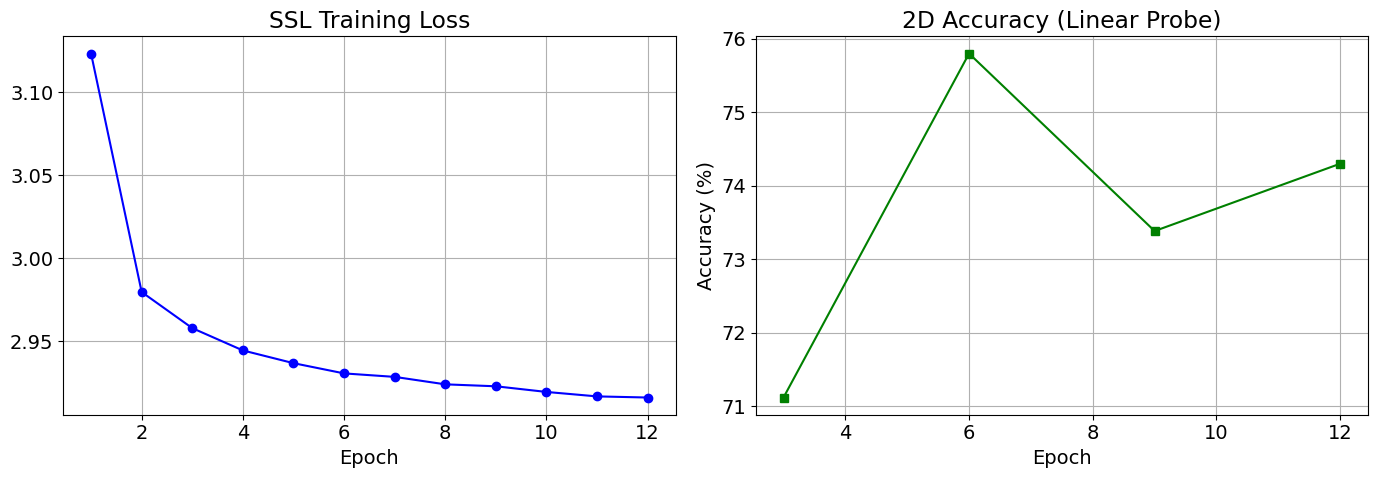

In [28]:
ssl_model = train_ssl_loop(max_epochs=12, probe_step=3)

#### CL + Augmented

In [29]:
clear_gpu_memory()

Loading params from ckpt...
Starting from epoch 12, best acc = 75.80%


Training: 0it [00:00, ?it/s]

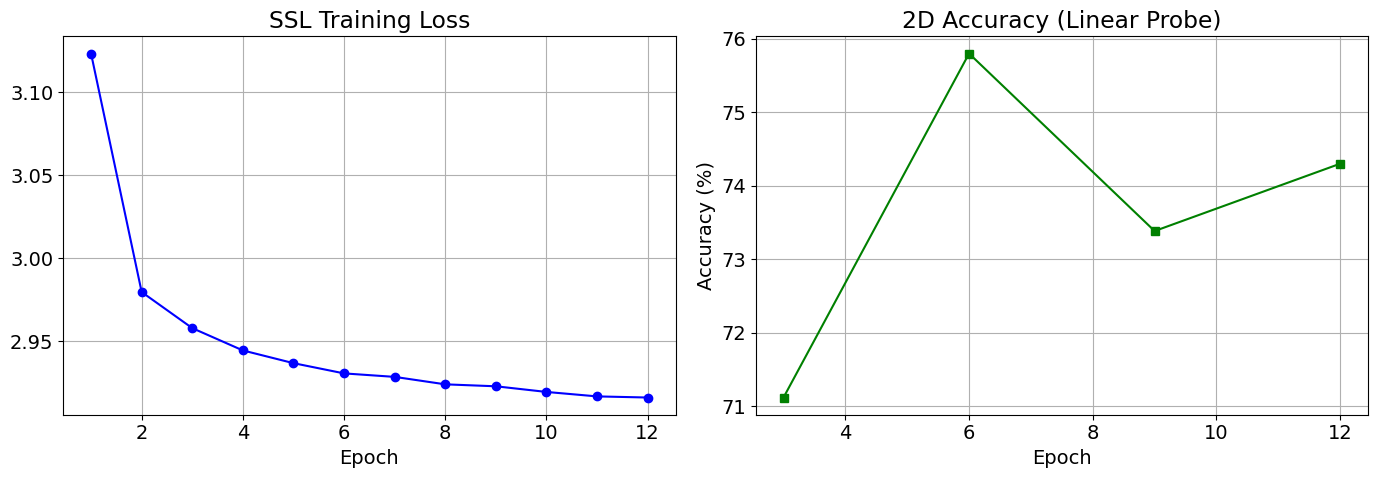

In [30]:
ssl_model_aug = train_ssl_loop(max_epochs=12, probe_step=3,
                               augment=True)

## Task 3(4 points)

Replace the InfoNCE loss in Multi-Format Contrastive Learning of Audio Representations with a Non-Contrastive Learning method.
Train the model until convergence, then plot the loss and accuracy curves to check that training has stabilized.

You can try one of the following NCL methods:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Feel free to use a more recent Non-Contrastive approach if you prefer—just explain briefly why you chose it.


WHY VicReg:
Симметричный неконтрастивный метод без отрицательных примеров, предотвращает схлопывание признаков математическими штрафами за дисперсию и ковариацию. Прост в реализации, максимально близок используемой архитектуре.

In [31]:
def off_diagonal(x):
    """возвращает матрицу без главной диагонали, свернутую в вектор"""
    n, m = x.shape
    assert n == m
    return x.flatten()[:-1].view(n - 1, n + 1)[:, 1:].flatten()

class VicRegLoss(nn.Module):
    def __init__(self, sim_coeff=25.0, var_coeff=25.0, cov_coeff=1.0):
        super().__init__()
        self.sim_coeff = sim_coeff # lambda
        self.var_coeff = var_coeff # mu
        self.cov_coeff = cov_coeff # nu

    def forward(self, z1, z2):
        # z1, z2: [B, D] (здесь: B=64, D=128)
        batch_size, dim = z1.shape

        # штраф за разницу между сырыми эмбеддингами
        sim_loss = F.mse_loss(z1, z2)

        # масштабируем
        z1_std = (z1 - z1.mean(dim=0)) / (z1.std(dim=0) + 1e-6)
        z2_std = (z2 - z2.mean(dim=0)) / (z2.std(dim=0) + 1e-6)

        # штраф за малую дисперсию: целевая = 1, штраф за std < 1
        std_z1 = torch.std(z1_std, dim=0)
        std_z2 = torch.std(z2_std, dim=0)
        var_loss = torch.mean(F.relu(1 - std_z1)) + torch.mean(F.relu(1 - std_z2))

        # штраф за корреляцию
        cov_z1 = (z1_std.T @ z1_std) / (batch_size - 1)
        cov_z2 = (z2_std.T @ z2_std) / (batch_size - 1)
        cov_loss = (off_diagonal(cov_z1).pow_(2).sum() / dim) + \
                   (off_diagonal(cov_z2).pow_(2).sum() / dim)

        # лосс
        loss = self.sim_coeff * sim_loss + self.var_coeff * var_loss + self.cov_coeff * cov_loss
        return loss

#### NCL + Not Augmented (MODEL RELOADED)

In [32]:
clear_gpu_memory()

Loading params from ckpt...
Starting from epoch 12, best acc = 75.80%


Training: 0it [00:00, ?it/s]

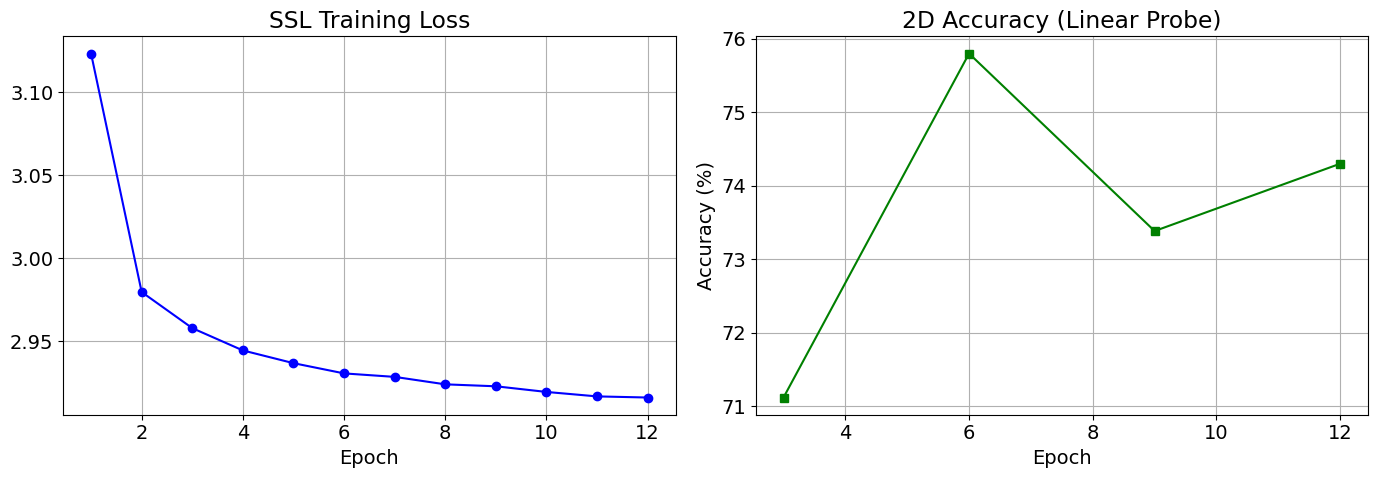

In [33]:
ssl_model_ncl = train_ssl_loop(max_epochs=12, probe_step=3,
                               augment=False,
                               ssl_loss=VicRegLoss
                               )

In [34]:
clear_gpu_memory()

Loading params from ckpt...
Starting from epoch 12, best acc = 75.80%


Training: 0it [00:00, ?it/s]

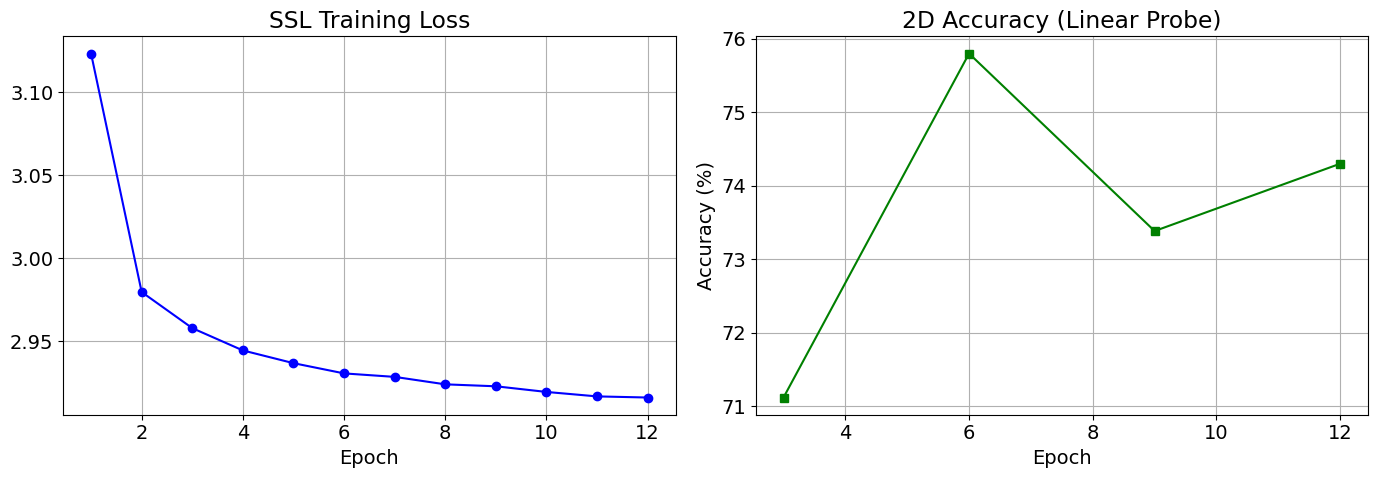

In [35]:
ssl_model_ncl = train_ssl_loop(max_epochs=12, probe_step=3,
                               augment=False,
                               ssl_loss=VicRegLoss
                               )

#### NCL + Augmented (INSERTED FROM KAGGLE)

In [36]:
clear_gpu_memory()

Loading params from ckpt...
Starting from epoch 12, best acc = 75.80%


Training: 0it [00:00, ?it/s]

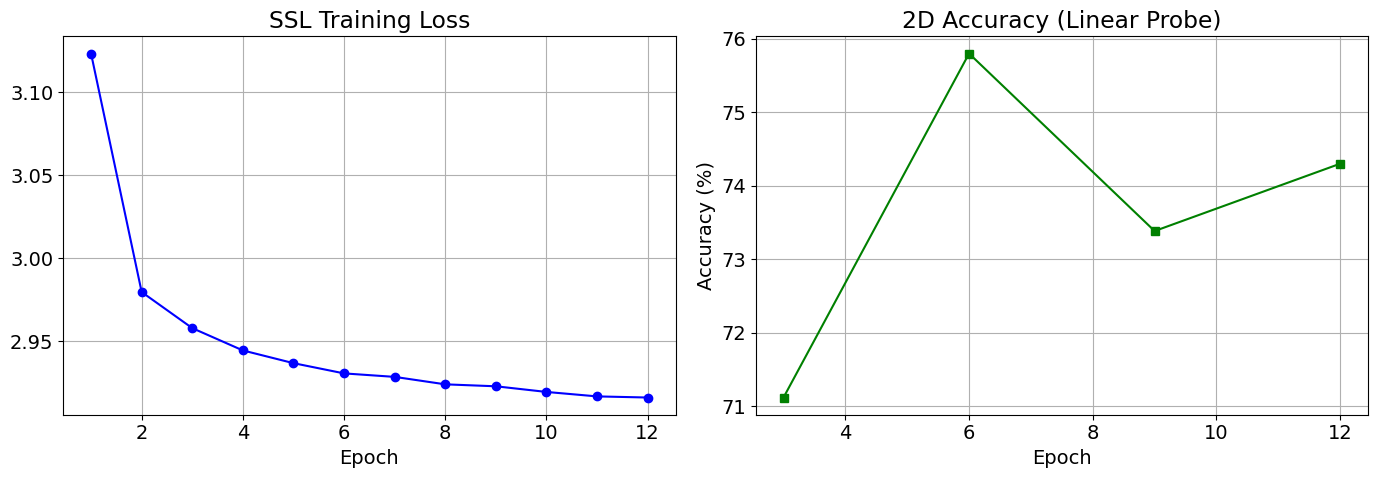

In [37]:
ssl_model_ncl_aug = train_ssl_loop(max_epochs=12, probe_step=3,
                                   augment=True,
                                   ssl_loss=VicRegLoss
                                   )

## Task 4(2 points)

Evaluate and compare three training setups on the validation subset:

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

Use either the 2D or 1D encoder—or combine their embeddings.
Identify which setup performs best and explain why it outperforms the others.

Везде использованы 2D-представления (логарифмированные мел-спектрограммы) как более легкие и качественные.

#### Baseline (supervised, LogMelSpectrograms)

In [38]:
model_2d = train_and_evaluate(format_type='spectrogram', epochs=5)

Training (spectrogram):   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/5 [Valid]:   0%|          | 0/47 [00:00<?, ?it/s]

  -> New best accuracy: 96.48%. Checkpoint saved to best_model_spectrogram.pt
Epoch 1: Loss = 0.1113 | Valid Accuracy = 96.48%



Epoch 2/5 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

...

Epoch 4/5 [Valid]:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 4: Loss = 0.0029 | Valid Accuracy = 96.47%



Epoch 5/5 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 5/5 [Valid]:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 5: Loss = 0.0065 | Valid Accuracy = 94.67%



#### CL + Not Augmented

In [ ]:
new_model = Net(img_channels=1, num_classes=10)
new_model = load_best_weights(new_model, 'cl_notaug_best_ssl.pt', device)

FileNotFoundError: [Errno 2] No such file or directory: 'cl_notaug_best_ssl.pt'

In [ ]:
clear_gpu_memory()

In [ ]:
all_preds, all_labels = test_ssl_inference(new_model,
                                           root,
                                           train_idxs,
                                           valid_idxs,
                                           device,
                                           probe_epochs=5)

Head training (inference):   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 1/5 | Loss: 1.1744


Epoch 2/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 2/5 | Loss: 0.7928


...

Epoch 4/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 4/5 | Loss: 0.6141


Epoch 5/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 5/5 | Loss: 0.5575


Inference evaluation:   0%|          | 0/47 [00:00<?, ?it/s]

In [ ]:
correct = sum(np.array(all_preds) == np.array(all_labels))
total = len(all_labels)
val_acc = correct / total * 100

print(f'val acc = {val_acc:.2f}%')

val acc = 77.17%


#### CL + Augmented

In [ ]:
new_model = Net(img_channels=1, num_classes=10)
new_model = load_best_weights(new_model, 'cl_aug_best_ssl.pt', device)

In [ ]:
clear_gpu_memory()

In [ ]:
all_preds, all_labels = test_ssl_inference(new_model,
                                           root,
                                           train_idxs,
                                           valid_idxs,
                                           device,
                                           probe_epochs=5)

Head training (inference):   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 1/5 | Loss: 0.9376


Epoch 2/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 2/5 | Loss: 0.9358


...

Epoch 4/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 4/5 | Loss: 0.5726


Epoch 5/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 5/5 | Loss: 0.6586


Inference evaluation:   0%|          | 0/47 [00:00<?, ?it/s]

In [ ]:
correct = sum(np.array(all_preds) == np.array(all_labels))
total = len(all_labels)
val_acc = correct / total * 100

print(f'val acc = {val_acc:.2f}%')

val acc = 77.90%


### NCL + Not Augmented

In [ ]:
new_model = Net(img_channels=1, num_classes=10)
new_model = load_best_weights(new_model, 'ncl_notaug_best_ssl.pt', device)

In [ ]:
clear_gpu_memory()

In [ ]:
all_preds, all_labels = test_ssl_inference(new_model,
                                           root,
                                           train_idxs,
                                           valid_idxs,
                                           device,
                                           5)

Head training (inference):   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 1/5 | Loss: 1.1051


Epoch 2/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 2/5 | Loss: 1.0380


...

Epoch 4/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 4/5 | Loss: 0.5712


Epoch 5/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 5/5 | Loss: 0.5895


Inference evaluation:   0%|          | 0/47 [00:00<?, ?it/s]

In [ ]:
correct = sum(np.array(all_preds) == np.array(all_labels))
total = len(all_labels)
val_acc = correct / total * 100

print(f'val acc = {val_acc:.2f}%')

val acc = 75.35%


### NCL + Augmented

In [ ]:
new_model = Net(img_channels=1, num_classes=10)
new_model = load_best_weights(new_model, 'ncl_aug_best_ssl.pt', device)

In [ ]:
clear_gpu_memory()

In [ ]:
all_preds, all_labels = test_ssl_inference(new_model,
                                           root,
                                           train_idxs,
                                           valid_idxs,
                                           device,
                                           5)

Head training (inference):   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 1/5 | Loss: 1.3347


Epoch 2/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 2/5 | Loss: 0.7817


...

Epoch 4/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 4/5 | Loss: 0.8869


Epoch 5/5:   0%|          | 0/188 [00:00<?, ?it/s]

Probe epoch 5/5 | Loss: 0.5836


Inference evaluation:   0%|          | 0/47 [00:00<?, ?it/s]

In [ ]:
correct = sum(np.array(all_preds) == np.array(all_labels))
total = len(all_labels)
val_acc = correct / total * 100

print(f'val acc = {val_acc:.2f}%')

val acc = 73.68%


#### Выводы

Результаты представлены в таблице ниже:

| No.| Approach | Augmented? | Val_ACC |
|-|-|-|-|
| 1 | Supervised 2D | No | 98.97 |
| 2 | InfoNCE | No | 77.17 |
| 3 | InfoNCE | Yes | 77.90 |
| 4 | VicReg | No | 75.35 |
| 5 | VicReg | Yes | 73.68 |



Наблюдения:

1. Supervised (98.97%) vs все остальные (~75-77%).
Причина: маленький набор, бэйзлайн-решение имеет прямой доступ к меткам класса. SSL-методы решают прокси-задачу (сравнение векторов), и им нужно больше данных -- как в наборе, так и в батче. На маленьких данных прямой метод обычно побеждает.

2. InfoNCE + аугментации (77.17% -> 77.90%).
Для InfoNCE нужно больше "сложных" положительных пар, иначе модель быстро находит простые лазейки. Аугментации повысили качество, заставив модель лучше понимать структуру звука. Рост небольшой, тк 5 эпох -- слишком мало, чтобы модель полностью адаптировалась к искажениям.

3. VicReg проиграл InfoNCE (75.35% vs 77.17%).
Предположительно, связано с размером батча (batch_size=64):
- InfoNCE работает на основе локальных сравнений (сэмпла с сэмплом), ему хватило 64 объектов, чтобы получить градиент;
- VicReg работает на основе глобальной статистики батча, ему нужно вычислять стандартное отклонение и ковариацию для каждого из 128 признаков по батчу. На батче из 64 элементов эти статистики сильно зашумлены, и VicReg не получил достаточно статистически достоверных данных, чтобы правильно "распределить" информацию.

4. Аугментации ухудшили VicReg (75.35% -> 73.68%). Вероятно, конфликт между штрафами или недостаточное количество эпох / экземпляров в батче для сходимости.

Таким образом, в данном случае прямой метод оказался сильнее всех. Тем не менее, все SSL-сетапы продемонстрировали способность к извлечению осмысленных признаков, и при увеличении объема данных, предположительно, картина могла бы существенно измениться.